<a href="https://colab.research.google.com/github/HitenPatil27/Task-6-K-Nearest-Neighbors-KNN-Classification/blob/main/Task_6_K_Nearest_Neighbors_(KNN)_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import Required Libraries & Load the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('/content/Iris.csv')
df.drop(columns=['Id'], inplace=True)

Step 2: Feature & Label Split

In [2]:
X = df.drop('Species', axis=1)
y = df['Species']

Step 3: Normalize the Features

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Step 4: Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Step 5: Train KNN with Different K values

In [5]:
accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

Step 6: Plot Accuracy vs K

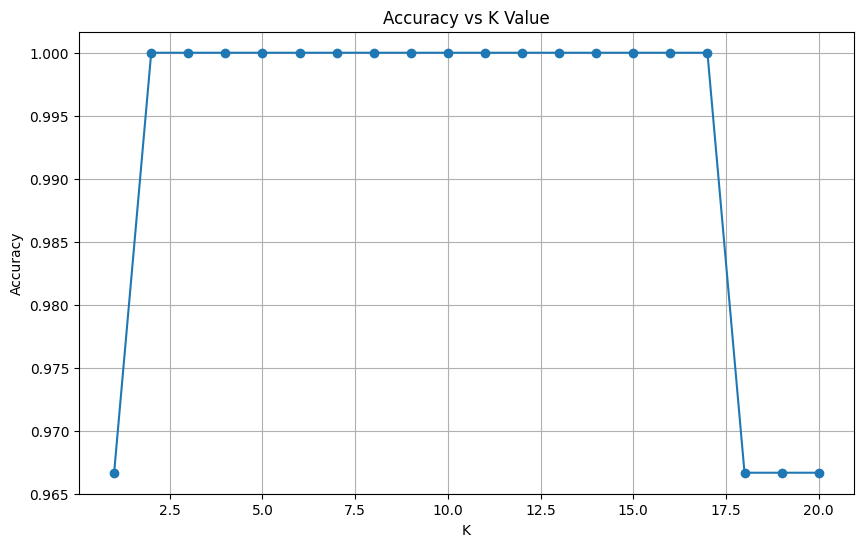

In [6]:
plt.figure(figsize=(10,6))
plt.plot(k_values, accuracies, marker='o')
plt.title('Accuracy vs K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

Step 7: Confusion Matrix for Best K

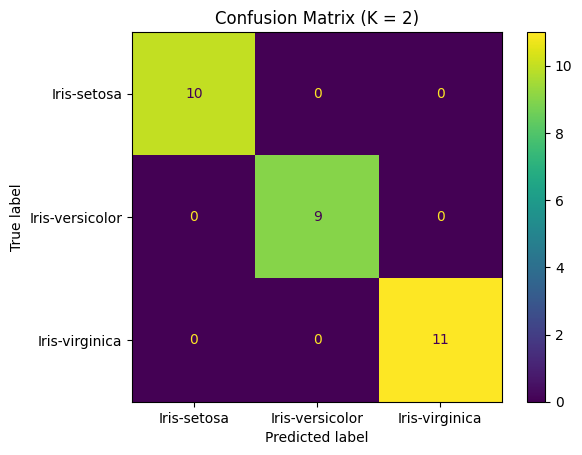

In [7]:
best_k = k_values[accuracies.index(max(accuracies))]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=knn_best.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_best.classes_)
disp.plot()
plt.title(f'Confusion Matrix (K = {best_k})')
plt.show()